In [263]:
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import pandas as pd
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import time
import requests
import numpy as np

In [265]:
def get_agro_data(parsing_type : str = 'static' ):
    assert parsing_type in ['static', 'dynamic'], f'{parsing_type} не поддерживатеся. Выберите static или dynamic'
    names = []
    prices = []
    if parsing_type == 'dynamic':
        driver = webdriver.Chrome()
        actions = ActionChains(driver)       
        for page in range(1, 8):
            driver.get(f"https://www.agrosadovod.ru/catalog/korma-dlya-ptits/kury/nesushek/page/{page}/")
            time.sleep(1.5)
            actions.send_keys(Keys.END).perform()
            time.sleep(1.5)
            names_list = driver.find_elements(By.CLASS_NAME, "product-loop-title")
            price_list = driver.find_elements(By.CLASS_NAME, "price")
            names += [name.text for name in names_list]
            prices += [int(price.text.split()[-2]) for price in price_list]
        driver.quit()
    else:
        for page in range(1, 8):
            html = requests.get(f"https://www.agrosadovod.ru/catalog/korma-dlya-ptits/kury/nesushek/page/{page}/").text
            soup = BeautifulSoup(html, 'lxml')
            goods_list = soup.findAll('a', class_ = 'product-loop-title')
            prices_list = soup.findAll('span', class_ = 'price')
            names += [good.text for good in goods_list]
            prices += [int(price.findAll(class_ = "woocommerce-Price-amount amount")[-1].text.split()[0]) for price in prices_list]
    d = dict(zip(names, prices))
    keys = []
    for name in d:
        if any(st in name.upper() for st in ["СМЕСЬ", "КОМБИКОРМ"]):
            keys.append(name)
    df_agro = pd.DataFrame({"Название" : keys, "Цена" : [d[key] for key in keys]})
    df_agro['КГ в мешке'] = df_agro['Название'].str.extract(r'(\d+) [Кк][Гг]')
    df_agro['КГ в мешке'] = pd.to_numeric(df_agro['КГ в мешке'])
    df_agro.dropna(inplace = True)
    df_agro["Цена за КГ"] = df_agro["Цена"] / df_agro["КГ в мешке"]
    df_agro['Магазин'] = 'Агросадовод'
    return df_agro


In [267]:
def get_ozon_data():
    options = webdriver.ChromeOptions()
    # подгружаем UserAgent своего браузера, чтобы обойти защиту Ozon от ботов
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36")
    # подгружаем профиль своего браузера, чтобы обойти защиту Ozon от ботов
    options.add_argument(r"user-data-dir=C:\Users\Yaroslav\AppData\Local\Google\Chrome\User Data")  
    options.add_argument('--profile-directory=Default')
    driver = webdriver.Chrome(options=options)
    actions = ActionChains(driver)
    prices = []
    names = []
    for i in range(10):
        url = f'https://www.ozon.ru/category/kombikorm-dlya-kur-nesushek/?page={1+4*i}&search_page_state=fDTeLRzirH_QScT9xHj04E-mPR822Or9HsRbpPNYt4yNMFH13pr6hyUrjoDLEES9s06f8rEN_8oQNI-8VZeOj60JuuKoog3v-xadvP1ncPFQwTEATdFvBLzEtL3LvP1WdHXqyrb5O1eNCvwrmku6U22fnhDQmlI22EJqcIrn-5JmgwMsSTkaWNCk5j4gNJ5Qmqu38_PYSX027K-RDp69C-OlDPPGQFjz4tQ3HPW-Uyk-k342t77g-rEyEWGGGG5F9mBd9w5w30twT7s0_T_5UQr2IkHBtidJDOCKpfn48V5k3VaaRSrRKav67fFwREf_MZey_xJhhIBqfHngM3mkTBRKBiAK6dvHi-kxXMXl2ZjHZ4G7g7R3Fs2rDxsGBpHmnkJKRdOvUeMT4W2kD6GT7sNOwrzRZg%3D%3D'
        driver.get(url)
        time.sleep(3)
        actions.send_keys(Keys.END).perform()
        time.sleep(3)
        actions.send_keys(Keys.END).perform()
        time.sleep(3)
        actions.send_keys(Keys.END).perform()
        goods = driver.find_elements(By.CLASS_NAME, "jm2_25.m2j_25.tile-root")
        nms = [good.find_element(By.CLASS_NAME, "tsBody500Medium") for good in goods]
        prcs = [int(''.join(good.find_element(By.CLASS_NAME, "c3025-a1.tsHeadline500Medium.c3025-b1.c3025-a6").text.split()[:-1])) for good in goods]
        names += [name.text for name in nms]
        prices += prcs
    d = dict(zip(names, prices))
    stop_words = ['добавк', 'витамин']
    cont_words = ['комбикорм', 'смес']
    names_to_save = []
    for name in d:
        if any(st in name.lower() for st in cont_words) and not any(st in name.lower() for st in stop_words) and ('кг' in name.lower()):
            names_to_save.append(name)
    df_ozon = pd.DataFrame({"Название" : names_to_save, "Цена" : [d[key] for key in names_to_save]})
    df_ozon['КГ в мешке'] = df_ozon['Название'].str.extract(r'(\d+)\s*[КкКк][Гг]')
    df_ozon['КГ в мешке'] = pd.to_numeric(df_ozon['КГ в мешке'])
    df_ozon['Цена за КГ'] = df_ozon['Цена'] / df_ozon['КГ в мешке']
    df_ozon['Магазин'] = 'Озон'
    driver.quit()
    return df_ozon

In [269]:
def get_nutrition_price():
    df_agro = get_agro_data('static')
    df_ozon = get_ozon_data()
    df = pd.concat([df_agro, df_ozon], ignore_index = True)
    df = df.sort_values(by='Цена за КГ')
    df = df.reset_index(drop = True)
    print(np.mean(df.loc[:10, "Цена за КГ"]))

In [277]:
df_agro = get_agro_data('static')
df_ozon = get_ozon_data()

In [279]:
df = pd.concat([df_agro, df_ozon], ignore_index = True)
df = df.sort_values(by='Цена за КГ')
df = df.reset_index(drop = True)

In [281]:
df

,Название,Цена,КГ в мешке,Цена за КГ,Магазин
0,Комбикорм для кур несушек комбинированный 10 к...,364,10.0,36.400000,Озон
1,Зерносмесь для птиц №4 (мешок 25 кг),1000,25.0,40.000000,Агросадовод
2,Комбикорм (кормосмесь) универсальный гранулиро...,1300,30.0,43.333333,Агросадовод
3,Зерносмесь для птиц 7 видов зерна (мешок 25 кг),1100,25.0,44.000000,Агросадовод
4,Комбикорм для кур несушек 25кг,1136,25.0,45.440000,Озон
...,...,...,...,...,...
202,ПК-4 Комбикорм гранулированный для НЕСУШКИ РАЗ...,437,3.0,145.666667,Озон
203,"Комбикорм для перепелов 5кг ДК-52, Глазовский ...",744,5.0,148.800000,Озон
204,Комбикорм полнорационный для ПЕРЕПЕЛОВ (старше...,453,3.0,151.000000,Озон
205,Комбикорм для молодняка кур в возрасте 0-7 нед...,958,5.0,191.600000,Озон


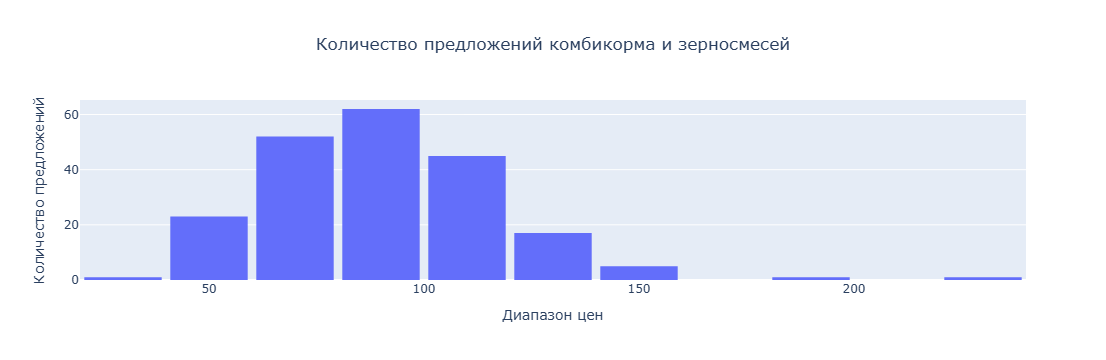

In [289]:
import pandas as pd
import plotly.express as px


fig = px.histogram(df, x="Цена за КГ", nbins=10, title="Количество предложений комбикорма и зерносмесей")

# Настраиваем оси и отображение
fig.update_layout(
    xaxis_title="Диапазон цен",
    yaxis_title="Количество предложений",
    bargap=0.1,  # Расстояние между столбцами,
    width = 800,
    title_x = 0.5
)

# Показываем график
fig.show()

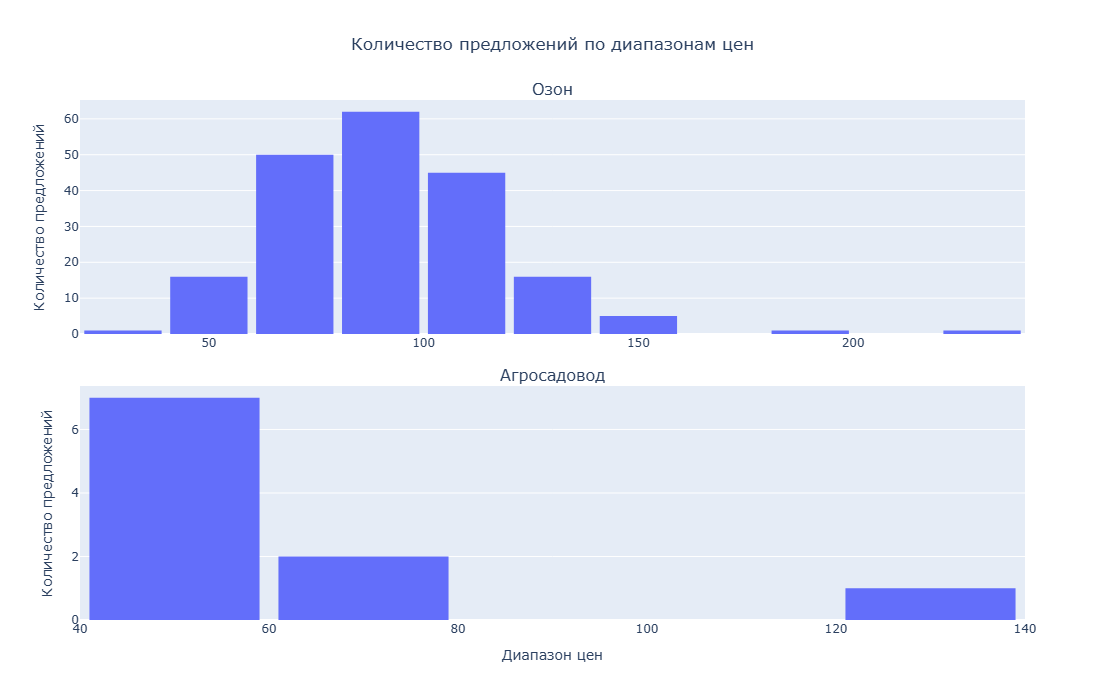

In [319]:
from plotly.subplots import make_subplots

fig_ozon = px.histogram(df_ozon, x="Цена за КГ", nbins=10, title="Озон")
fig_agro = px.histogram(df_agro, x="Цена за КГ", nbins=10, title="Агросадовод")

fig = make_subplots(rows=2, cols=1, subplot_titles=("Озон", "Агросадовод"), vertical_spacing=0.1)

fig.add_trace(fig_ozon.data[0], row=1, col=1)
fig.add_trace(fig_agro.data[0], row=2, col=1)

fig.update_layout(
    title_text="Количество предложений по диапазонам цен",
    xaxis_title="Диапазон цен",
    yaxis_title="Количество предложений",
    bargap=0.1,
    height = 700,
    width = 700,
    title_x = 0.5
)

fig.update_xaxes(title_text="", row=1, col=1)  # Ось X для первого графика
fig.update_xaxes(title_text="Диапазон цен", row=2, col=1)
fig.update_yaxes(title_text="Количество предложений", row=2, col=1)

# Показываем график
fig.show()

In [ ]:
options = webdriver.ChromeOptions()
# подгружаем UserAgent своего браузера, чтобы обойти защиту Ozon от ботов
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safari/537.36")
# подгружаем профиль своего браузера, чтобы обойти защиту Ozon от ботов
options.add_argument(r"user-data-dir=C:\Users\Yaroslav\AppData\Local\Google\Chrome\User Data")  
options.add_argument('--profile-directory=Default')
driver = webdriver.Chrome(options=options)
actions = ActionChains(driver)
prices = []
names = []
for i in range(10):
    url = f'https://www.ozon.ru/category/kombikorm-dlya-kur-nesushek/?page={1+4*i}&search_page_state=fDTeLRzirH_QScT9xHj04E-mPR822Or9HsRbpPNYt4yNMFH13pr6hyUrjoDLEES9s06f8rEN_8oQNI-8VZeOj60JuuKoog3v-xadvP1ncPFQwTEATdFvBLzEtL3LvP1WdHXqyrb5O1eNCvwrmku6U22fnhDQmlI22EJqcIrn-5JmgwMsSTkaWNCk5j4gNJ5Qmqu38_PYSX027K-RDp69C-OlDPPGQFjz4tQ3HPW-Uyk-k342t77g-rEyEWGGGG5F9mBd9w5w30twT7s0_T_5UQr2IkHBtidJDOCKpfn48V5k3VaaRSrRKav67fFwREf_MZey_xJhhIBqfHngM3mkTBRKBiAK6dvHi-kxXMXl2ZjHZ4G7g7R3Fs2rDxsGBpHmnkJKRdOvUeMT4W2kD6GT7sNOwrzRZg%3D%3D'
    driver.get(url)
    time.sleep(3)
    actions.send_keys(Keys.END).perform()
    time.sleep(3)
    actions.send_keys(Keys.END).perform()
    time.sleep(3)
    actions.send_keys(Keys.END).perform()
    goods = driver.find_elements(By.CLASS_NAME, "jm2_25.m2j_25.tile-root")
    nms = [good.find_element(By.CLASS_NAME, "tsBody500Medium") for good in goods]
    prcs = [int(''.join(good.find_element(By.CLASS_NAME, "c3025-a1.tsHeadline500Medium.c3025-b1.c3025-a6").text.split()[:-1])) for good in goods]
    names += [name.text for name in nms]
    prices += prcs
    break

,Название,Цена,КГ в мешке,Цена за КГ,Магазин
0,"Комбикорм для кур несушек ""Ряба"" (Несушка прод...",1459,20,72.95,Озон
1,"Комбикорм для кур Несушек 20-45 недель, 5кг",445,5,89.00,Озон
2,"Комбикорм для кур Несушек 20-45 недель, 10кг",719,10,71.90,Озон
3,"Комбикорм для кур несушек 20-45 недель, 20кг",1372,20,68.60,Озон
4,"Комбикорм для для яйценосной птицы ""Сытный"" (д...",741,10,74.10,Озон
...,...,...,...,...,...
165,Комбикорм полнорационный гранулированный для Г...,469,5,93.80,Озон
166,"Комбикорм для кур-несушек 10кг ПК1,2,3 от 45 н...",1187,10,118.70,Озон
167,Комбикорм ПК-2 для кур-несушек старт 10 кг,1004,10,100.40,Озон
168,Комбикорм 10 кг куры-несушки от 45 недель ПК1-2-3,1255,10,125.50,Озон
